# Compute Region Densities

Paper: ...

Problem: Our actor network is "too big" -> Even an untrained actor has a region density of 1 for the offline trajectories.

## Merge regions

Idea: Reduce the state space by "merging" linear regions

For now, we reduce the state space by creating groups of neurons with size x, and check if at least one neuron in this group is active, or if all are 0.
We do the grouping by halving the state space multiple times (for the plots below its 5 times leading to a dim reduction of `dim / (2*5))`

Results: First results seem to show that there is a difference in region densities between training and test trajectories, as well as between successful and failed test trajectories.

In [1]:
import numpy as np
from analyze import compute_training_states, get_sorted_param_paths, compute_transitions, compute_test_states
from tqdm.auto import tqdm


# checkpoints
folder = "../exp/checkpoints/"
param_paths = get_sorted_param_paths(folder)

/raven/u/nmilosevic/workspace/ogbench/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ["MUJOCO_GL"]="osmesa"

In [3]:
# Compute the training states for 100 trajectories, for the first 100 training steps (param_paths[:100]) and the fully trained model
train_states = compute_training_states(folder, param_paths[:100] + param_paths[-1:], n_trajectories=100, include_initial=True)

100%|██████████| 4/4 [00:38<00:00,  9.66s/it]


In [4]:
train_states.keys()

dict_keys([PosixPath('initial'), PosixPath('../exp/checkpoints/params_5000.pkl'), PosixPath('../exp/checkpoints/params_1000000.pkl')])

In [5]:
# Halve states and compute transitions
data_points, n_halving = [], 5
for path, trajectories in tqdm(train_states.items()):
    densities = []
    for trajectory_states in trajectories:
        n_transitions, n_actions = compute_transitions(trajectory_states, n_halving=n_halving)
        densities.append(n_transitions/n_actions)
    data_points.append(densities)
#data_points = np.array(data_points).T

100%|██████████| 3/3 [00:33<00:00, 11.22s/it]


In [6]:
data_points[-1]

[0.04585043547902693,
 0.08849734708178997,
 0.07848633496846531,
 0.10711782961257384,
 0.0655721293422765,
 0.06336970667734508,
 0.06887576333967364,
 0.07237961757933727,
 0.09049954950445491,
 0.08178996896586245,
 0.06807488237060767,
 0.08479327259985985,
 0.06937631394533987,
 0.1006106717389128,
 0.0788867754529983,
 0.1038141956151767,
 0.09960957052758034,
 0.0918009810791871,
 0.0378416257883672,
 0.09750725798378217,
 0.08869756732405647,
 0.10601661828010812,
 0.09760736810491541,
 0.10731804985484032,
 0.11372509760736811,
 0.0831915106617279,
 0.09910901992191411,
 0.10311342476724397,
 0.09370307338071879,
 0.10141155270797877,
 0.026228851736910603,
 0.09240164180598659,
 0.08709580538592451,
 0.08499349284212634,
 0.06467113825207728,
 0.0933026328961858,
 0.0933026328961858,
 0.09890879967964761,
 0.1141255380919011,
 0.09029932926218841,
 0.036339973971368504,
 0.08799679647612374,
 0.08609470417459206,
 0.09150065071578736,
 0.1051156271899089,
 0.0965061567724497

In [6]:
print("Original dim:", 512*3)
print("Compression ratio:", (2**5))
print("New dim:", 512 / (2**5))

Original dim: 1536
Compression ratio: 32
New dim: 16.0


ValueError: x and y must have same first dimension, but have shapes (99,) and (199,)

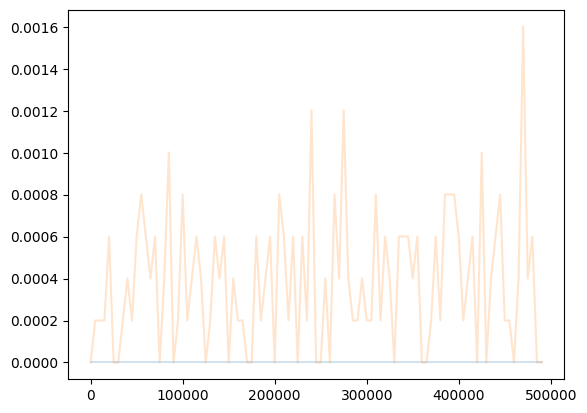

In [7]:
import matplotlib.pyplot as plt

x = np.array(range(len(data_points[0][:-1]))) * 5000
        
for values in data_points:
    plt.plot(x, values[:-1], alpha=0.2)

mean = data_points[:, :-1].mean(axis=0)
std = data_points[:, :-1].std(axis=0)
plt.fill_between(x, mean - std, mean + std, alpha=0.4, color="C0")
plt.xlabel("Training Steps")
plt.ylabel("Region Density")

In [ ]:
test_states = compute_test_states(folder, param_paths[-1], n_trajectories=100, pbar=False)

Restored from exp/OGBench/Debug/sd000_s_1134105.0.20250716_161902/params_1000000.pkl


  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# Halve states and compute transitions
densities_success, densities_fail, n_halving = [], [], 5
for trajectory in tqdm(test_states):
    states = trajectory[0]
    n_transitions, n_actions = compute_transitions(states, n_halving=n_halving)
    if trajectory[1]:  # If the trajectory was successful
        densities_success.append(n_transitions/n_actions)
    else:  # If the trajectory failed
        densities_fail.append(n_transitions/n_actions)

  0%|          | 0/100 [00:00<?, ?it/s]

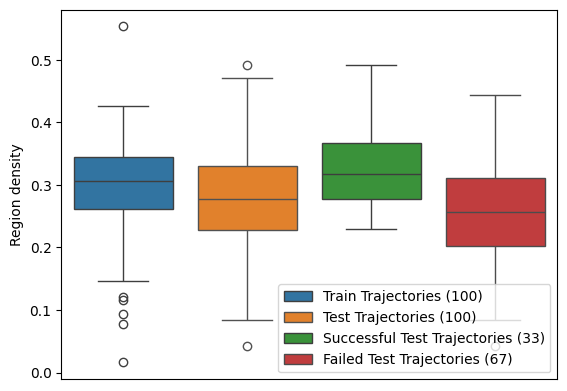

In [44]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.boxplot(y=data_points[:, -1], x=0, label=f"Train Trajectories ({len(data_points)})")
sns.boxplot(y=densities_success+densities_fail, x=1, label=f"Test Trajectories ({len(densities_success) + len(densities_fail)})")
sns.boxplot(y=densities_success, x=2, label=f"Successful Test Trajectories ({len(densities_success)})")
sns.boxplot(y=densities_fail, x=3, label=f"Failed Test Trajectories ({len(densities_fail)})")
plt.ylabel("Region density")
plt.gca().get_xaxis().set_visible(False)
#plt.ylim(0.96, 1.01)

# Interpolate trajectories

Idea: Interpolate between observations 

Results: It seems that the observation space is too high -> Even for the training trajectories, the interpolated observations seem to "new"/"unexplored" ...

In [1]:

from analyze import compute_training_states, get_sorted_param_paths, compute_transitions
from pathlib import Path
import numpy as np


folder = Path("exp/OGBench/Debug/sd000_s_1134105.0.20250716_161902")
param_paths = get_sorted_param_paths(folder)

In [3]:
states = compute_training_states(
    folder=folder, 
    param_paths=param_paths[-1:], 
    n_trajectories=100, 
    n_interpolations=499, 
    batch_size=125000, 
    max_obs_per_trajectory=50000
)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [4]:
from tqdm.auto import tqdm

# compute transitions
data_points = []
for path, trajectories in tqdm(states.items()):
    densities = []
    for trajectory_states in trajectories:
        n_transitions, n_actions = compute_transitions(trajectory_states)
        densities.append(n_transitions/n_actions)
    data_points.append(densities)
data_points = np.array(data_points).T
data_points.shape

  0%|          | 0/2 [00:00<?, ?it/s]

(100, 2)

In [14]:
data_points;

Text(0, 0.5, 'Region Density')

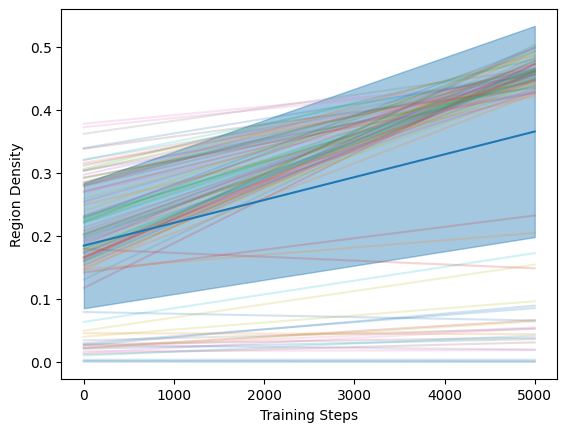

In [5]:
import matplotlib.pyplot as plt

x = np.array(range(len(data_points[0][:]))) * 5000
        
for values in data_points:
    plt.plot(x, values[:], alpha=0.2)

mean = data_points[:, :].mean(axis=0)
std = data_points[:, :].std(axis=0)
plt.plot(x, mean, color="C0", label="Mean Region Density")
plt.fill_between(x, mean - std, mean + std, alpha=0.4, color="C0")
plt.xlabel("Training Steps")
plt.ylabel("Region Density")

In [6]:
del states

In [7]:
from analyze import compute_test_states

test_states, test_observations, actor = compute_test_states(folder, param_paths[-1], n_trajectories=100, pbar=False, return_observations_and_actor=True)

Restored from exp/OGBench/Debug/sd000_s_1134105.0.20250716_161902/params_1000000.pkl


  0%|          | 0/100 [00:00<?, ?it/s]

In [20]:
from analyze import interpolate, compute_states

test_trajectory_states = []
for obs in tqdm(test_observations):
    obs = interpolate(obs, n_interpolations=499)
    states = compute_states(obs, actor=actor, max_obs_per_trajectory=50000)
    test_trajectory_states.append(states)

  0%|          | 0/100 [00:00<?, ?it/s]

In [21]:
from tqdm.auto import tqdm

densities_success, densities_fail, n_halving = [], [], 0
for(_, success), states in tqdm(zip(test_states, test_trajectory_states)):
    n_transitions, n_actions = compute_transitions(states, n_halving=n_halving)
    if success:  # If the trajectory was successful
        densities_success.append(n_transitions/n_actions)
    else:  # If the trajectory failed
        densities_fail.append(n_transitions/n_actions)

0it [00:00, ?it/s]

(0.4, 0.55)

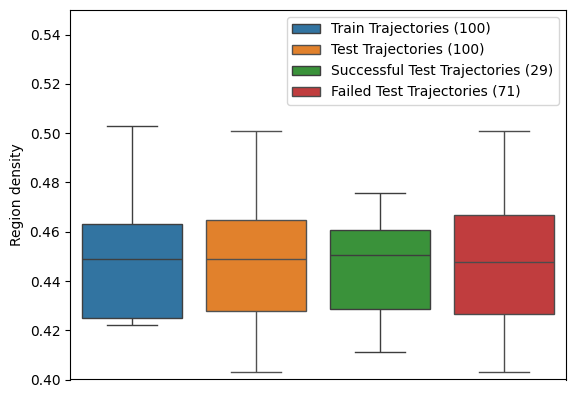

In [23]:

import seaborn as sns
from matplotlib import pyplot as plt

sns.boxplot(y=data_points[:, -1], x=0, label=f"Train Trajectories ({len(data_points)})")
sns.boxplot(y=densities_success+densities_fail, x=1, label=f"Test Trajectories ({len(densities_success) + len(densities_fail)})")
sns.boxplot(y=densities_success, x=2, label=f"Successful Test Trajectories ({len(densities_success)})")
sns.boxplot(y=densities_fail, x=3, label=f"Failed Test Trajectories ({len(densities_fail)})")
plt.ylabel("Region density")
plt.gca().get_xaxis().set_visible(False)
plt.ylim(0.4, 0.55)